In [ ]:
# =========================================================
# CELL 1
# Data + PCHIP/Akima + Models + Hyperparameter Grids
# =========================================================

!pip install -q scipy scikit-learn

import numpy as np
import pandas as pd
import warnings

from scipy.interpolate import (
    PchipInterpolator,
    Akima1DInterpolator
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, GridSearchCV

from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    RBF,
    Matern,
    RationalQuadratic,
    WhiteKernel
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42


# =========================================================
# 1. ORIGINAL 9-POINT AVERAGED DATASET
# =========================================================

condition = np.arange(1, 10, dtype=float)

sludge = np.array([
    0,
    1,
    2.5,
    5,
    10,
    20,
    20,
    20,
    30
], dtype=float)

plasticizer = np.array([
    0,
    0,
    0,
    0,
    0,
    0,
    0.5,
    1.0,
    2.5
], dtype=float)

gf = np.array([
    0.000,
    0.143,
    0.042,
    0.484,
    0.765,
    1.081,
    1.105,
    4.794,
    1.464
], dtype=float)


ORIGINAL_DF = pd.DataFrame({
    "Condition_Index": condition,
    "Sludge": sludge,
    "Plasticizer": plasticizer,
    "GF_end": gf
})

print("Original averaged dataset:")
display(ORIGINAL_DF)


# =========================================================
# 2. CREATE 17-POINT CONDITION INDEX
# =========================================================

condition_new = np.arange(
    1.0,
    9.01,
    0.5
)


# =========================================================
# 3. PCHIP INTERPOLATION
# =========================================================

pchip_sludge = PchipInterpolator(
    condition,
    sludge
)

pchip_plasticizer = PchipInterpolator(
    condition,
    plasticizer
)

pchip_gf = PchipInterpolator(
    condition,
    gf
)


PCHIP_DF = pd.DataFrame({

    "Condition_Index":
        condition_new,

    "Sludge":
        pchip_sludge(condition_new),

    "Plasticizer":
        pchip_plasticizer(condition_new),

    "GF_end":
        pchip_gf(condition_new)
})


PCHIP_DF["Data_Type"] = np.where(
    PCHIP_DF["Condition_Index"] % 1 == 0,
    "Original",
    "Interpolated"
)


# =========================================================
# 4. AKIMA INTERPOLATION
# =========================================================

akima_sludge = Akima1DInterpolator(
    condition,
    sludge
)

akima_plasticizer = Akima1DInterpolator(
    condition,
    plasticizer
)

akima_gf = Akima1DInterpolator(
    condition,
    gf
)


AKIMA_DF = pd.DataFrame({

    "Condition_Index":
        condition_new,

    "Sludge":
        akima_sludge(condition_new),

    "Plasticizer":
        akima_plasticizer(condition_new),

    "GF_end":
        akima_gf(condition_new)
})


AKIMA_DF["Data_Type"] = np.where(
    AKIMA_DF["Condition_Index"] % 1 == 0,
    "Original",
    "Interpolated"
)


print("\nPCHIP dataset:")
display(PCHIP_DF.round(4))

print("\nAkima dataset:")
display(AKIMA_DF.round(4))


# =========================================================
# 5. ANN
# =========================================================

ANN = Pipeline([
    ("scaler", StandardScaler()),

    ("model", MLPRegressor(
        max_iter=10000,
        random_state=RANDOM_STATE
    ))
])


ANN_GRID = {

    "model__hidden_layer_sizes": [
        (4,),
        (6,),
        (8,),
        (12,)
    ],

    "model__activation": [
        "relu",
        "tanh"
    ],

    "model__solver": [
        "lbfgs"
    ],

    "model__alpha": [
        0.001,
        0.01,
        0.1
    ]
}


# =========================================================
# 6. SVR
# =========================================================

SVR_MODEL = Pipeline([
    ("scaler", StandardScaler()),

    ("model", SVR())
])


SVR_GRID = {

    "model__kernel": [
        "rbf"
    ],

    "model__C": [
        0.1,
        1,
        10,
        100
    ],

    "model__epsilon": [
        0.01,
        0.1,
        0.2
    ],

    "model__gamma": [
        "scale",
        0.1,
        1
    ]
}


# =========================================================
# 7. GPR
# Two input variables
# =========================================================

GPR_KERNELS = [

    C(1.0) *
    RBF(
        length_scale=np.ones(2)
    )
    + WhiteKernel(
        noise_level=0.01
    ),

    C(1.0) *
    Matern(
        length_scale=np.ones(2),
        nu=1.5
    )
    + WhiteKernel(
        noise_level=0.01
    ),

    C(1.0) *
    RationalQuadratic(
        length_scale=1.0,
        alpha=1.0
    )
    + WhiteKernel(
        noise_level=0.01
    )
]


GPR_MODEL = Pipeline([
    ("scaler", StandardScaler()),

    ("model", GaussianProcessRegressor(
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=RANDOM_STATE
    ))
])


GPR_GRID = {

    "model__kernel":
        GPR_KERNELS,

    "model__alpha": [
        1e-10,
        1e-6,
        1e-4
    ]
}


print("\nEverything is prepared successfully.")

Original averaged dataset:


,Condition_Index,Sludge,Plasticizer,GF_end
0,1.0,0.0,0.0,0.000
1,2.0,1.0,0.0,0.143
2,3.0,2.5,0.0,0.042
3,4.0,5.0,0.0,0.484
4,5.0,10.0,0.0,0.765
5,6.0,20.0,0.0,1.081
6,7.0,20.0,0.5,1.105
7,8.0,20.0,1.0,4.794
8,9.0,30.0,2.5,1.464



PCHIP dataset:


,Condition_Index,Sludge,Plasticizer,GF_end,Data_Type
0,1.0,0.0000,0.0000,0.0000,Original
1,1.5,0.4438,0.0000,0.1046,Interpolated
2,2.0,1.0000,0.0000,0.1430,Original
3,2.5,1.6656,0.0000,0.0925,Interpolated
4,3.0,2.5000,0.0000,0.0420,Original
5,3.5,3.5677,0.0000,0.2201,Interpolated
6,4.0,5.0000,0.0000,0.4840,Original
7,4.5,7.0833,0.0000,0.6303,Interpolated
8,5.0,10.0000,0.0000,0.7650,Original
9,5.5,15.8333,0.0000,0.9546,Interpolated



Akima dataset:


,Condition_Index,Sludge,Plasticizer,GF_end,Data_Type
0,1.0,0.0000,0.0000,0.0000,Original
1,1.5,0.4479,0.0000,0.0962,Interpolated
2,2.0,1.0000,0.0000,0.1430,Original
3,2.5,1.6875,0.0000,0.0727,Interpolated
4,3.0,2.5000,0.0000,0.0420,Original
5,3.5,3.5938,0.0000,0.2549,Interpolated
6,4.0,5.0000,0.0000,0.4840,Original
7,4.5,7.1146,0.0000,0.6242,Interpolated
8,5.0,10.0000,0.0000,0.7650,Original
9,5.5,15.7500,-0.0312,0.9205,Interpolated



Everything is prepared successfully.


In [ ]:
# =========================================================
# CELL 2
# Nested LOOCV + Model Comparison + Best Hyperparameters
# =========================================================


# =========================================================
# 1. METRICS
# =========================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)


    r2 = r2_score(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    # MAPE excluding zero actual GF
    mask = np.abs(y_true) > 1e-12


    if np.any(mask):

        mape = (
            np.mean(
                np.abs(
                    (
                        y_true[mask]
                        -
                        y_pred[mask]
                    )
                    /
                    y_true[mask]
                )
            )
            * 100
        )

    else:

        mape = np.nan


    return {

        "R2":
            r2,

        "RMSE":
            rmse,

        "MAE":
            mae,

        "MAPE":
            mape
    }


# =========================================================
# 2. NESTED LOOCV
# =========================================================

def nested_loocv(
    model,
    param_grid,
    X,
    y
):

    outer_cv = LeaveOneOut()

    actual = []
    predicted = []


    for train_idx, test_idx in (
        outer_cv.split(X)
    ):


        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]


        # Inner LOOCV for hyperparameter selection
        inner_cv = LeaveOneOut()


        grid_search = GridSearchCV(

            estimator=model,

            param_grid=param_grid,

            scoring=
                "neg_root_mean_squared_error",

            cv=inner_cv,

            n_jobs=-1,

            refit=True
        )


        grid_search.fit(
            X_train,
            y_train
        )


        prediction = (
            grid_search
            .best_estimator_
            .predict(X_test)[0]
        )


        actual.append(
            y_test[0]
        )

        predicted.append(
            prediction
        )


    actual = np.asarray(actual)
    predicted = np.asarray(predicted)


    return {

        "actual":
            actual,

        "predicted":
            predicted,

        "metrics":
            calculate_metrics(
                actual,
                predicted
            )
    }


# =========================================================
# 3. RUN ONE DATASET
# =========================================================

def run_models(
    dataframe,
    interpolation_name
):

    X_current = dataframe[
        [
            "Sludge",
            "Plasticizer"
        ]
    ].to_numpy(dtype=float)


    y_current = dataframe[
        "GF_end"
    ].to_numpy(dtype=float)


    results = {}


    results["ANN"] = nested_loocv(
        ANN,
        ANN_GRID,
        X_current,
        y_current
    )


    results["GPR"] = nested_loocv(
        GPR_MODEL,
        GPR_GRID,
        X_current,
        y_current
    )


    results["SVR"] = nested_loocv(
        SVR_MODEL,
        SVR_GRID,
        X_current,
        y_current
    )


    rows = []


    for model_name in [
        "ANN",
        "GPR",
        "SVR"
    ]:

        m = results[
            model_name
        ]["metrics"]


        rows.append({

            "Interpolation":
                interpolation_name,

            "Model":
                model_name,

            "R²":
                m["R2"],

            "RMSE":
                m["RMSE"],

            "MAE":
                m["MAE"],

            "MAPE (%)":
                m["MAPE"]
        })


    return (
        results,
        rows
    )


# =========================================================
# 4. RUN PCHIP
# =========================================================

PCHIP_RESULTS, pchip_rows = run_models(
    PCHIP_DF,
    "PCHIP"
)


# =========================================================
# 5. RUN AKIMA
# =========================================================

AKIMA_RESULTS, akima_rows = run_models(
    AKIMA_DF,
    "Akima"
)


# =========================================================
# 6. FINAL MODEL PERFORMANCE TABLE
# =========================================================

MODEL_PERFORMANCE = pd.DataFrame(
    pchip_rows
    +
    akima_rows
)


MODEL_PERFORMANCE = (
    MODEL_PERFORMANCE
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("FINAL MODEL PERFORMANCE")
print("=" * 75)

display(
    MODEL_PERFORMANCE.round(4)
)


# =========================================================
# 7. FINAL HYPERPARAMETER OPTIMIZATION
# =========================================================

MODEL_CONFIGS = {

    "ANN":
        (
            ANN,
            ANN_GRID
        ),

    "GPR":
        (
            GPR_MODEL,
            GPR_GRID
        ),

    "SVR":
        (
            SVR_MODEL,
            SVR_GRID
        )
}


datasets = {

    "PCHIP":
        PCHIP_DF,

    "Akima":
        AKIMA_DF
}


FINAL_MODELS = {}
config_rows = []


for dataset_name, dataframe in (
    datasets.items()
):


    X_current = dataframe[
        [
            "Sludge",
            "Plasticizer"
        ]
    ].to_numpy(dtype=float)


    y_current = dataframe[
        "GF_end"
    ].to_numpy(dtype=float)


    loo = LeaveOneOut()


    for model_name, (
        model,
        param_grid
    ) in MODEL_CONFIGS.items():


        search = GridSearchCV(

            estimator=model,

            param_grid=param_grid,

            scoring=
                "neg_root_mean_squared_error",

            cv=loo,

            n_jobs=-1,

            refit=True
        )


        search.fit(
            X_current,
            y_current
        )


        FINAL_MODELS[
            (
                dataset_name,
                model_name
            )
        ] = search.best_estimator_


        config_rows.append({

            "Interpolation":
                dataset_name,

            "Model":
                model_name,

            "CV RMSE":
                -search.best_score_,

            "Best Parameters":
                str(
                    search.best_params_
                )
        })


        print(
            "\n" +
            "=" * 70
        )

        print(
            dataset_name,
            "-",
            model_name
        )

        print(
            "=" * 70
        )


        print(
            "Best CV RMSE =",
            round(
                -search.best_score_,
                4
            )
        )


        print(
            "Best parameters:"
        )


        for key, value in (
            search
            .best_params_
            .items()
        ):

            print(
                key,
                "=",
                value
            )


        if model_name == "GPR":

            print(
                "\nOptimized kernel:"
            )

            print(
                search
                .best_estimator_
                .named_steps[
                    "model"
                ]
                .kernel_
            )


# =========================================================
# 8. CONFIGURATION TABLE
# =========================================================

CONFIG_TABLE = pd.DataFrame(
    config_rows
)


print("\n" + "=" * 75)
print("FINAL OPTIMIZED CONFIGURATIONS")
print("=" * 75)

display(
    CONFIG_TABLE
)


FINAL MODEL PERFORMANCE


,Interpolation,Model,R²,RMSE,MAE,MAPE (%)
0,PCHIP,GPR,0.8846,0.4676,0.2785,51.7584
1,PCHIP,SVR,0.8476,0.5374,0.3661,56.7450
2,Akima,GPR,0.8422,0.5505,0.2886,52.6236
3,Akima,SVR,0.8378,0.5583,0.3508,47.6203
4,PCHIP,ANN,0.7945,0.6239,0.3577,63.1897
5,Akima,ANN,0.7449,0.7001,0.3463,62.3255



PCHIP - ANN
Best CV RMSE = 0.2177
Best parameters:
model__activation = tanh
model__alpha = 0.01
model__hidden_layer_sizes = (12,)
model__solver = lbfgs

PCHIP - GPR
Best CV RMSE = 0.248
Best parameters:
model__alpha = 1e-06
model__kernel = 1**2 * Matern(length_scale=[1, 1], nu=1.5) + WhiteKernel(noise_level=0.01)

Optimized kernel:
1.43**2 * Matern(length_scale=[5.95, 0.991], nu=1.5) + WhiteKernel(noise_level=0.00302)

PCHIP - SVR
Best CV RMSE = 0.2584
Best parameters:
model__C = 10
model__epsilon = 0.1
model__gamma = 1
model__kernel = rbf

Akima - ANN
Best CV RMSE = 0.224
Best parameters:
model__activation = tanh
model__alpha = 0.01
model__hidden_layer_sizes = (12,)
model__solver = lbfgs

Akima - GPR
Best CV RMSE = 0.1749
Best parameters:
model__alpha = 0.0001
model__kernel = 1**2 * Matern(length_scale=[1, 1], nu=1.5) + WhiteKernel(noise_level=0.01)

Optimized kernel:
1.44**2 * Matern(length_scale=[5.96, 1.08], nu=1.5) + WhiteKernel(noise_level=0.00278)

Akima - SVR
Best CV RMSE = 0.

,Interpolation,Model,CV RMSE,Best Parameters
0,PCHIP,ANN,0.217677,"{'model__activation': 'tanh', 'model__alpha': ..."
1,PCHIP,GPR,0.248015,"{'model__alpha': 1e-06, 'model__kernel': 1**2 ..."
2,PCHIP,SVR,0.258384,"{'model__C': 10, 'model__epsilon': 0.1, 'model..."
3,Akima,ANN,0.224029,"{'model__activation': 'tanh', 'model__alpha': ..."
4,Akima,GPR,0.174920,"{'model__alpha': 0.0001, 'model__kernel': 1**2..."
5,Akima,SVR,0.190504,"{'model__C': 100, 'model__epsilon': 0.1, 'mode..."


In [ ]:
# ============================================================
# EXPORT ACTUAL vs PREDICTED VALUES TO EXCEL
# PCHIP + Akima | ANN + GPR + SVR
# Uses nested-LOOCV out-of-fold predictions
# ============================================================

import numpy as np
import pandas as pd
from google.colab import files

# ------------------------------------------------------------
# Condition index of the 17-point interpolated datasets
# 9 original + 8 interpolated points
# ------------------------------------------------------------
condition_index = np.arange(1.0, 9.5, 0.5)

data_type = [
    "Original" if float(x).is_integer() else "Interpolated"
    for x in condition_index
]

# ------------------------------------------------------------
# Collect all model results
# ------------------------------------------------------------
all_results = {
    "PCHIP": PCHIP_RESULTS,
    "Akima": AKIMA_RESULTS
}

output_file = "GF_Actual_vs_Predicted.xlsx"

summary_rows = []

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # ========================================================
    # Separate sheet for each model
    # ========================================================
    for interpolation_name, results_dict in all_results.items():

        for model_name in ["ANN", "GPR", "SVR"]:

            result = results_dict[model_name]

            actual = np.asarray(result["actual"]).ravel()
            predicted = np.asarray(result["predicted"]).ravel()

            # Safety check
            if len(actual) != len(predicted):
                raise ValueError(
                    f"{interpolation_name}-{model_name}: "
                    f"Actual and predicted lengths are different."
                )

            # If 17 points are present, use condition indices
            if len(actual) == 17:
                idx = condition_index
                dtype = data_type
            else:
                idx = np.arange(1, len(actual) + 1)
                dtype = ["Sample"] * len(actual)

            residual = actual - predicted
            absolute_error = np.abs(residual)

            df = pd.DataFrame({
                "Condition Index": idx,
                "Data Type": dtype,
                "Actual GF_end": actual,
                "Predicted GF_end": predicted,
                "Residual (Actual - Predicted)": residual,
                "Absolute Error": absolute_error
            })

            sheet_name = f"{interpolation_name}_{model_name}"
            df.to_excel(
                writer,
                sheet_name=sheet_name[:31],
                index=False
            )

            # ------------------------------------------------
            # Performance summary
            # ------------------------------------------------
            metrics = result["metrics"]

            summary_rows.append({
                "Interpolation": interpolation_name,
                "Model": model_name,
                "R2": metrics["R2"],
                "RMSE": metrics["RMSE"],
                "MAE": metrics["MAE"],
                "MAPE (%)": metrics["MAPE"]
            })

    # ========================================================
    # Combined Actual vs Predicted sheet
    # ========================================================
    combined_rows = []

    for interpolation_name, results_dict in all_results.items():

        for model_name in ["ANN", "GPR", "SVR"]:

            actual = np.asarray(
                results_dict[model_name]["actual"]
            ).ravel()

            predicted = np.asarray(
                results_dict[model_name]["predicted"]
            ).ravel()

            if len(actual) == 17:
                idx = condition_index
                dtype = data_type
            else:
                idx = np.arange(1, len(actual) + 1)
                dtype = ["Sample"] * len(actual)

            for i in range(len(actual)):
                combined_rows.append({
                    "Interpolation": interpolation_name,
                    "Model": model_name,
                    "Condition Index": idx[i],
                    "Data Type": dtype[i],
                    "Actual GF_end": actual[i],
                    "Predicted GF_end": predicted[i],
                    "Residual": actual[i] - predicted[i],
                    "Absolute Error": abs(actual[i] - predicted[i])
                })

    combined_df = pd.DataFrame(combined_rows)
    combined_df.to_excel(
        writer,
        sheet_name="All_Predictions",
        index=False
    )

    # ========================================================
    # Performance summary sheet
    # ========================================================
    summary_df = pd.DataFrame(summary_rows)

    summary_df = summary_df.sort_values(
        by="R2",
        ascending=False
    )

    summary_df.to_excel(
        writer,
        sheet_name="Performance_Summary",
        index=False
    )

print(f"Excel file created successfully: {output_file}")

# Download
files.download(output_file)

Excel file created successfully: GF_Actual_vs_Predicted.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Font loaded: Times New Roman

Best model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GaussianProcessRegressor(alpha=1e-06,
                                          kernel=1**2 * Matern(length_scale=[1, 1], nu=1.5) + WhiteKernel(noise_level=0.01),
                                          n_restarts_optimizer=5,
                                          normalize_y=True, random_state=42))])


  0%|          | 0/17 [00:00<?, ?it/s]


SHAP shape: (17, 2)


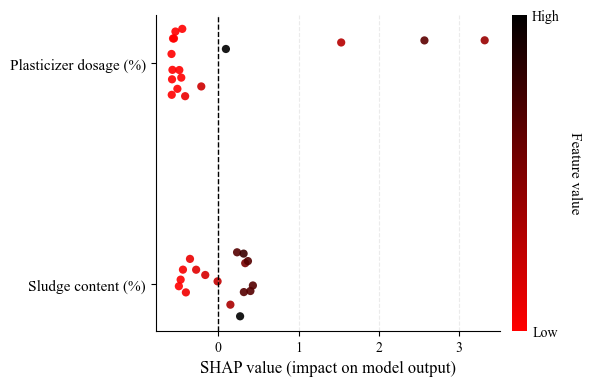


Figure saved:
/content/PCHIP_GPR_SHAP_Summary.jpg

SHAP values saved:
/content/PCHIP_GPR_SHAP_Values.xlsx


In [ ]:
# ============================================================
# SHAP SUMMARY PLOT
# Best model: PCHIP + GPR
# Theme: Times New Roman | Red -> Black | Journal style
# ============================================================

# If needed:
# !pip install shap

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.interpolate import PchipInterpolator
import shap

# ============================================================
# 1. TIMES NEW ROMAN FONT
# Upload your Times New Roman .ttf/.otf file to Colab
# ============================================================

font_files = glob.glob("/content/*.ttf") + glob.glob("/content/*.otf")

times_fonts = [
    f for f in font_files
    if "times" in os.path.basename(f).lower()
]

if len(times_fonts) > 0:
    font_path = times_fonts[0]
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    print("Font loaded:", font_name)
else:
    font_name = "Times New Roman"
    print("Times New Roman file not found. Using system fallback.")

mpl.rcParams["font.family"] = font_name
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 11

# ============================================================
# 2. ORIGINAL AVERAGED EXPERIMENTAL DATA
# ============================================================

condition_original = np.arange(1, 10, dtype=float)

sludge_original = np.array([
    0.0,
    1.0,
    2.5,
    5.0,
    10.0,
    20.0,
    20.0,
    20.0,
    30.0
])

plasticizer_original = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.5,
    1.0,
    2.5
])

gf_original = np.array([
    0.000,
    0.143,
    0.042,
    0.484,
    0.765,
    1.081,
    1.105,
    4.7936666667,
    1.4636666667
])

# ============================================================
# 3. RECREATE THE 17-POINT PCHIP DATASET
# ============================================================

condition_pchip = np.arange(1.0, 9.01, 0.5)

sludge_pchip = PchipInterpolator(
    condition_original,
    sludge_original
)(condition_pchip)

plasticizer_pchip = PchipInterpolator(
    condition_original,
    plasticizer_original
)(condition_pchip)

gf_pchip = PchipInterpolator(
    condition_original,
    gf_original
)(condition_pchip)

feature_names = [
    "Sludge content (%)",
    "Plasticizer dosage (%)"
]

X_pchip = pd.DataFrame({
    feature_names[0]: sludge_pchip,
    feature_names[1]: plasticizer_pchip
})

# Use the 9 original experimental conditions as SHAP background
X_background = pd.DataFrame({
    feature_names[0]: sludge_original,
    feature_names[1]: plasticizer_original
})

# ============================================================
# 4. BEST MODEL: PCHIP-GPR
# ============================================================

best_model = FINAL_MODELS[("PCHIP", "GPR")]

print("\nBest model:")
print(best_model)

# ============================================================
# 5. SHAP VALUES
# ============================================================

def prediction_function(X):
    X = pd.DataFrame(
        np.asarray(X),
        columns=feature_names
    )
    return best_model.predict(X)


explainer = shap.KernelExplainer(
    prediction_function,
    X_background
)

shap_values = explainer.shap_values(
    X_pchip,
    nsamples="auto"
)

shap_values = np.asarray(shap_values)

# Compatibility with different SHAP versions
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print("\nSHAP shape:", shap_values.shape)

# ============================================================
# 6. FEATURE IMPORTANCE ORDER
# ============================================================

mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

# Most important feature first
order = np.argsort(-mean_abs_shap)

# ============================================================
# 7. RED -> BLACK COLORMAP
# Low = Red
# High = Black
# ============================================================

red_black_cmap = LinearSegmentedColormap.from_list(
    "RedBlack",
    ["#FF0000", "#000000"]
)

norm = Normalize(
    vmin=0,
    vmax=1
)

# ============================================================
# 8. CUSTOM SHAP SUMMARY PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 4)
)

np.random.seed(42)

for row, feature_idx in enumerate(order):

    shap_feature = shap_values[:, feature_idx]

    feature_values = X_pchip.iloc[
        :, feature_idx
    ].values.astype(float)

    # Normalize feature value for color mapping
    f_min = np.min(feature_values)
    f_max = np.max(feature_values)

    if f_max > f_min:
        normalized_values = (
            feature_values - f_min
        ) / (
            f_max - f_min
        )
    else:
        normalized_values = np.zeros_like(
            feature_values
        )

    # Small vertical jitter for beeswarm appearance
    jitter = np.random.uniform(
        -0.16,
        0.16,
        size=len(shap_feature)
    )

    y_position = row + jitter

    ax.scatter(
        shap_feature,
        y_position,
        c=normalized_values,
        cmap=red_black_cmap,
        norm=norm,
        s=35,
        alpha=0.90,
        edgecolors="none"
    )

# ============================================================
# 9. AXIS STYLE
# ============================================================

ax.set_yticks(
    np.arange(len(order))
)

ax.set_yticklabels(
    [feature_names[i] for i in order],
    fontname=font_name
)

# Most important feature at the top
ax.invert_yaxis()

ax.set_xlabel(
    "SHAP value (impact on model output)",
    fontname=font_name,
    fontsize=12
)


# Zero reference line
ax.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

# Only x-direction grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

# Clean journal-style frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ============================================================
# 10. COLORBAR
# ============================================================

sm = mpl.cm.ScalarMappable(
    cmap=red_black_cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.03,
    fraction=0.055
)

cbar.set_ticks([0, 1])

cbar.set_ticklabels([
    "Low",
    "High"
])

cbar.set_label(
    "Feature value",
    rotation=270,
    labelpad=16,
    fontname=font_name,
    fontsize=11
)

# Remove colorbar border and tick marks
cbar.outline.set_visible(False)

cbar.ax.tick_params(
    length=0,
    labelsize=10
)

for label in cbar.ax.get_yticklabels():
    label.set_fontname(font_name)

# Font for x-axis tick labels
for label in ax.get_xticklabels():
    label.set_fontname(font_name)

plt.tight_layout()

# ============================================================
# 11. SAVE FIGURE
# ============================================================

output_path = "/content/PCHIP_GPR_SHAP_Summary.jpg"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\nFigure saved:")
print(output_path)

# ============================================================
# 12. EXPORT SHAP VALUES TO EXCEL
# ============================================================

shap_output = pd.DataFrame({
    "Condition Index": condition_pchip,
    "Sludge content (%)": sludge_pchip,
    "Plasticizer dosage (%)": plasticizer_pchip,
    "PCHIP GF_end": gf_pchip,
    "Predicted GF_end": best_model.predict(X_pchip),
    "SHAP - Sludge content": shap_values[:, 0],
    "SHAP - Plasticizer dosage": shap_values[:, 1]
})

excel_path = "/content/PCHIP_GPR_SHAP_Values.xlsx"

shap_output.to_excel(
    excel_path,
    index=False
)

print("\nSHAP values saved:")
print(excel_path)